In [4]:
import random
import numpy as np
import torch

In [5]:
SEED =4
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# NETWORK ARCHITECTURE

NUM_ROUTERS = 5
NUM_HUBS = 5
# CPU FREQUENCIES
ROUTER_FORWARDING_DELAY = 0.005
HUB_CPU = [5e9] * NUM_HUBS
CLOUD_CPU = 5e9

# TASK PARAMETERS

TASK_SIZE_MIN = 0.3
TASK_SIZE_MAX = 3.5

CPU_CYCLE_MIN = 1300
CPU_CYCLE_MAX = 3400

# ENERGY & COST PARAMS

KAPPA = 1e-27      # Energy coefficient (standard MEC value)
P_TX_ROUTER = 0.5        # Transmission power edge→router (Watts)
P_TX_HUB = 1.0        # Transmission power router→hub (Watts)
P_TX_CLOUD = 2.0        # Transmission power hub→cloud (Watts)

COST_ALPHA = 0.4        # Energy weight in cost
COST_BETA = 0.4        # Latency weight in cost
COST_GAMMA = 0.2        # Bandwidth weight in cost

In [6]:
PRIORITY_THRESHOLD = 0.5

def generate_task():

    return {

        "size_mb": random.uniform(
            TASK_SIZE_MIN,
            TASK_SIZE_MAX
        ),

        "cycles_per_byte": random.uniform(
            CPU_CYCLE_MIN,
            CPU_CYCLE_MAX
        ),

        "priority": random.uniform(0, 1),

    }


router_queue = [0] * NUM_ROUTERS

router_load = [

    random.uniform(10, 90)

    for _ in range(NUM_ROUTERS)

]

router_bandwidth = [

    random.uniform(20, 100)

    for _ in range(NUM_ROUTERS)

]

hub_queue = [0] * NUM_HUBS

hub_load = [

    random.uniform(10, 90)

    for _ in range(NUM_HUBS)

]

hub_bandwidth = [

    random.uniform(50, 200)

    for _ in range(NUM_HUBS)

]

In [7]:
# Dynamic load changes

router_load = [

    min(
        100,
        max(
            0,
            load + random.uniform(-5, 5)
        )
    )

    for load in router_load
]

hub_load = [

    min(
        100,
        max(
            0,
            load + random.uniform(-5, 5)
        )
    )

    for load in hub_load
]

In [8]:
router_queue = [

    random.randint(0, 5)

    for _ in range(NUM_ROUTERS)

]

hub_queue = [

    random.randint(0, 5)

    for _ in range(NUM_HUBS)

]

In [9]:
def router_delay_breakdown(
    task,
    router_id
):

    size_mb = task["size_mb"]

    # D1
    edge_to_router = (

        size_mb * 8

        /

        router_bandwidth[
            router_id
        ]

    )

    # D2
    queue_delay = (
        router_queue[router_id]
        * 0.05
    )

    # D3
    forwarding_delay = (

        ROUTER_FORWARDING_DELAY*(1 + router_load[router_id] / 100))

    return {

        "D1_edge_router_tx":
        edge_to_router,

        "D2_router_queue":
        queue_delay,

        "D3_router_processing":
        forwarding_delay

    }

In [10]:
def hub_delay_breakdown(
    task,
    hub_id
):

    size_mb = task["size_mb"]

    # D4
    router_to_hub = (
        size_mb * 8
        /
        hub_bandwidth[hub_id]
    )

    # D5
    queue_delay = (
        hub_queue[hub_id]
        * 0.05
    )

    size_bytes = (
        size_mb
        * 1024
        * 1024
    )

    total_cycles = (
        size_bytes
        *
        task["cycles_per_byte"]
    )

    effective_cpu = (

        HUB_CPU[hub_id]

        *

        (
            1 -
            hub_load[hub_id] / 100
        )

    )

    effective_cpu = max(
        effective_cpu,
        0.1 * HUB_CPU[hub_id]
    )

    processing_delay = (

        total_cycles
        /
        effective_cpu
    )

    return {

        "D4_router_hub_tx":
        router_to_hub,

        "D5_hub_queue":
        queue_delay,

        "D6_hub_processing":
        processing_delay

    }

In [11]:
def cloud_delay_breakdown(
    task
):

    size_mb = task["size_mb"]

    # D7

    hub_to_cloud = (
        size_mb * 8
        /
        300
    )

    size_bytes = (
        size_mb
        * 1024
        * 1024
    )

    total_cycles = (
        size_bytes
        *
        task["cycles_per_byte"]
    )

    # D8

    cloud_processing = (
        total_cycles
        /
        CLOUD_CPU
    )

    return {

        "D7_hub_cloud_tx":
        hub_to_cloud,

        "D8_cloud_processing":
        cloud_processing

    }

In [12]:
def compute_energy(task, router_id, hub_id):

    size_bytes = task["size_mb"] * 1024 * 1024
    total_cycles = size_bytes * task["cycles_per_byte"]

    # Computation energy at hub
    E_comp = KAPPA * (HUB_CPU[hub_id] ** 2) * total_cycles

    # Transmission energy D1 + D4 + D7
    r_delays = router_delay_breakdown(task, router_id)
    h_delays = hub_delay_breakdown(task, hub_id)
    c_delays = cloud_delay_breakdown(task)

    E_tx = (
        P_TX_ROUTER * r_delays["D1_edge_router_tx"]
        + P_TX_HUB * h_delays["D4_router_hub_tx"]
        + P_TX_CLOUD * c_delays["D7_hub_cloud_tx"]
    )

    E_total = E_comp + E_tx

    return {
        "E_comp":  E_comp,
        "E_tx":    E_tx,
        "E_total": E_total
    }


def compute_cost(task, router_id, hub_id, latency, energy):

    avg_bandwidth = (
        router_bandwidth[router_id]
        + hub_bandwidth[hub_id]
    ) / 2

    cost = (
        COST_ALPHA * energy["E_total"]
        + COST_BETA * latency
        + COST_GAMMA * (1.0 / avg_bandwidth)
    )

    return cost

In [13]:
def total_latency(
    task,
    router_id,
    hub_id
):

    router_part = router_delay_breakdown(
        task,
        router_id
    )

    hub_part = hub_delay_breakdown(
        task,
        hub_id
    )

    cloud_part = cloud_delay_breakdown(
        task
    )

    return (

        sum(router_part.values())

        +

        sum(hub_part.values())

        +

        sum(cloud_part.values())

    )

In [14]:
NUM_TASKS = 3000

delay_sums = {
    "D1": 0,
    "D2": 0,
    "D3": 0,
    "D4": 0,
    "D5": 0,
    "D6": 0,
    "D7": 0,
    "D8": 0
}

for _ in range(NUM_TASKS):

    task = generate_task()

    r = random.randint(0, NUM_ROUTERS - 1)
    h = random.randint(0, NUM_HUBS - 1)

    router_part = router_delay_breakdown(task, r)
    hub_part = hub_delay_breakdown(task, h)
    cloud_part = cloud_delay_breakdown(task)

    # Task enters queues

    router_queue[r] += 1
    hub_queue[h] += 1

    # Accumulate delays

    delay_sums["D1"] += router_part["D1_edge_router_tx"]
    delay_sums["D2"] += router_part["D2_router_queue"]
    delay_sums["D3"] += router_part["D3_router_processing"]

    delay_sums["D4"] += hub_part["D4_router_hub_tx"]
    delay_sums["D5"] += hub_part["D5_hub_queue"]
    delay_sums["D6"] += hub_part["D6_hub_processing"]

    delay_sums["D7"] += cloud_part["D7_hub_cloud_tx"]
    delay_sums["D8"] += cloud_part["D8_cloud_processing"]

    # Queue service

    for i in range(NUM_ROUTERS):

        if random.random() < 0.15:

            router_queue[i] = max(
                0,
                router_queue[i] - 1
            )

    for i in range(NUM_HUBS):

        if random.random() < 0.15:

            hub_queue[i] = max(
                0,
                hub_queue[i] - 1
            )


# DELAY BREAKDOWN


print("\n===== AVERAGE DELAY BREAKDOWN =====\n")

delay_names = {

    "D1": "Edge → Router Transmission",

    "D2": "Router Queue Delay",

    "D3": "Router Forwarding Delay",

    "D4": "Router → Hub Transmission",

    "D5": "Hub Queue Delay",

    "D6": "Hub Processing Delay",

    "D7": "Hub → Cloud Transmission",

    "D8": "Cloud Processing Delay"

}

avg_total_latency = 0

for k, v in delay_sums.items():

    avg_delay = v / NUM_TASKS

    avg_total_latency += avg_delay

    print(
        f"{k:<3} ({delay_names[k]:<28}) "
        f": {avg_delay:.4f} sec"
    )


# DELAY CATEGORIES


transmission_delay = (

    delay_sums["D1"]

    + delay_sums["D4"]

    + delay_sums["D7"]

) / NUM_TASKS

queue_delay = (

    delay_sums["D2"]

    + delay_sums["D5"]

) / NUM_TASKS

processing_delay = (

    delay_sums["D3"]

    + delay_sums["D6"]

    + delay_sums["D8"]

) / NUM_TASKS


# PERCENT CONTRIBUTION


transmission_percent = (
    transmission_delay
    /
    avg_total_latency
) * 100

queue_percent = (
    queue_delay
    /
    avg_total_latency
) * 100

processing_percent = (
    processing_delay
    /
    avg_total_latency
) * 100

print("\n===== DELAY CATEGORY SUMMARY =====\n")

print(
    f"Transmission Delay : "
    f"{transmission_delay:.4f} sec,     ({transmission_percent:.2f}%)"
)

print(
    f"Queue Delay        : "
    f"{queue_delay:.4f} sec ,       ({queue_percent:.2f}%)"
)

print(
    f"Processing Delay   : "
    f"{processing_delay:.4f} sec,       ({processing_percent:.2f}%)"
)

print(
    f"\nTotal Latency      : "
    f"{avg_total_latency:.4f} sec"
)

print("\n===== FINAL QUEUES =====\n")

print(
    "Router Queues :",
    router_queue
)

print(
    "Hub Queues    :",
    hub_queue
)


===== AVERAGE DELAY BREAKDOWN =====

D1  (Edge → Router Transmission  ) : 0.2467 sec
D2  (Router Queue Delay          ) : 3.9627 sec
D3  (Router Forwarding Delay     ) : 0.0064 sec
D4  (Router → Hub Transmission   ) : 0.1086 sec
D5  (Hub Queue Delay             ) : 4.1832 sec
D6  (Hub Processing Delay        ) : 1.3715 sec
D7  (Hub → Cloud Transmission    ) : 0.0506 sec
D8  (Cloud Processing Delay      ) : 0.9340 sec

===== DELAY CATEGORY SUMMARY =====

Transmission Delay : 0.4059 sec,     (3.74%)
Queue Delay        : 8.1459 sec ,       (74.98%)
Processing Delay   : 2.3119 sec,       (21.28%)

Total Latency      : 10.8636 sec

===== FINAL QUEUES =====

Router Queues : [181, 151, 142, 149, 145]
Hub Queues    : [171, 168, 165, 153, 145]


In [15]:
%pip install stable-baselines3 gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 66.4 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


In [16]:
import gymnasium as gym

from gymnasium import spaces

import numpy as np

from stable_baselines3 import PPO

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
class OffloadingEnv(gym.Env):

    def __init__(self):

        super().__init__()

        self.current_step = 0
        self.max_steps = 100

        self.action_space = spaces.Discrete(25)

        self.observation_space = spaces.Box(

            low=0,
            high=100,

            shape=(33,),

            dtype=np.float32

        )

    def get_state(self):
        # Store sorted indices as instance variables
        self.sorted_router_idx = sorted(
            range(NUM_ROUTERS), key=lambda i: router_queue[i])
        self.sorted_hub_idx = sorted(
            range(NUM_HUBS), key=lambda i: hub_queue[i])

        state = [
            self.task["size_mb"] / TASK_SIZE_MAX,
            self.task["cycles_per_byte"] / CPU_CYCLE_MAX,
            self.task["priority"],
            *[router_queue[i] / 5 for i in self.sorted_router_idx],
            *[router_load[i] / 100 for i in self.sorted_router_idx],
            *[router_bandwidth[i] / 100 for i in self.sorted_router_idx],
            *[hub_queue[i] / 5 for i in self.sorted_hub_idx],
            *[hub_load[i] / 100 for i in self.sorted_hub_idx],
            *[hub_bandwidth[i] / 200 for i in self.sorted_hub_idx],
        ]

        return np.array(state, dtype=np.float32)

    def reset(
        self,
        seed=None,
        options=None
    ):

        super().reset(seed=seed)

        global router_queue
        global hub_queue

        global router_load
        global hub_load

        # Reset queues

        router_queue = [0] * NUM_ROUTERS

        hub_queue = [0] * NUM_HUBS

        # Reset loads
        router_load = [

            random.uniform(10, 90)

            for _ in range(NUM_ROUTERS)

        ]

        hub_load = [

            random.uniform(10, 90)

            for _ in range(NUM_HUBS)

        ]

        # Episode counter
        self.current_step = 0
        self.task = generate_task()
        obs = self.get_state()
        return obs, {}


    def step(self, action):
        global router_queue
        global hub_queue
        global router_load
        global hub_load
        _ = self.get_state()

        router_pos = action // NUM_HUBS
        hub_pos = action % NUM_HUBS

        router_id = self.sorted_router_idx[router_pos]
        hub_id = self.sorted_hub_idx[hub_pos]


        # Task enters system
        router_queue[router_id] += 1
        hub_queue[hub_id] += 1


        # Dynamic load updates
        router_load = [

            min(
                100,
                max(
                    0,
                    load + random.uniform(-10, 10)
                )
            )

            for load in router_load

        ]

        hub_load = [

            min(
                100,
                max(
                    0,
                    load + random.uniform(-10, 10)
                )
            )

            for load in hub_load

        ]


        # Queue servicing
        for i in range(NUM_ROUTERS):
            if random.random() < 0.15:
                router_queue[i] = max(
                    0,
                    router_queue[i] - 1
                )
        for i in range(NUM_HUBS):
            if random.random() < 0.15:
                hub_queue[i] = max(
                    0,
                    hub_queue[i] - 1
                )
        latency = total_latency(
            self.task,
            router_id,
            hub_id
        )

        # CONGESTION-AWARE REWARD


        best_router_q = min(router_queue)
        best_hub_q = min(hub_queue)

        priority = self.task.get("priority", 0.5)
        priority_scale = 1.5 if priority > PRIORITY_THRESHOLD else 1.0

        energy = compute_energy(self.task, router_id, hub_id)

        reward = -priority_scale * (
            latency
            + 0.1 * energy["E_total"]
            + 5.0 * (router_queue[router_id] - best_router_q)
            + 8.0 * (hub_queue[hub_id]       - best_hub_q)
            + 0.5 * router_load[router_id]
            + 1.5 * hub_load[hub_id]
)
        self.task = generate_task()

        obs = self.get_state()

        self.current_step += 1

        terminated = (self.current_step >= self.max_steps)
        truncated = False

        info = {

            "latency": latency,
            "router_queue":router_queue.copy(),
            "hub_queue":hub_queue.copy(),
            "router_id":router_id,
            "hub_id":hub_id

        }

        return (
            obs,
            reward,
            terminated,
            truncated,
            info
        )

In [18]:
env = OffloadingEnv()

obs, _ = env.reset(seed=SEED)

print(obs.shape)

(33,)


In [19]:
env = OffloadingEnv()

model = PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,

    gamma=0.99,

    ent_coef=0.01,
    seed=SEED,
    verbose=1

)

model.learn(

    total_timesteps=200000

)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 100       |
|    ep_rew_mean     | -2.04e+04 |
| time/              |           |
|    fps             | 550       |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 2048      |
----------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 100           |
|    ep_rew_mean          | -2.05e+04     |
| time/                   |               |
|    fps                  | 331           |
|    iterations           | 2             |
|    time_elapsed         | 12            |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00012315135 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -3.22         |
|    explained_variance   | -4.7e-

In [20]:
ppo_energy_total    = 0.0
ppo_cost_total      = 0.0
random_energy_total = 0.0
random_cost_total   = 0.0

In [21]:
NUM_TESTS = 1000

random_router_usage = [0] * NUM_ROUTERS
random_hub_usage = [0] * NUM_HUBS

random_latencies = []
random_delay_sums = {f"D{i}": 0.0 for i in range(1, 9)}

import copy
obs, _ = env.reset(seed=SEED)
saved_env_state = {
    'router_queue': router_queue.copy(),
    'hub_queue': hub_queue.copy(),
    'router_load': router_load.copy(),
    'hub_load': hub_load.copy()
}
for _ in range(NUM_TESTS):
    router_id = random.randint(0, NUM_ROUTERS - 1)
    hub_id = random.randint(0, NUM_HUBS - 1)

    r_delays = router_delay_breakdown(env.task, router_id)
    h_delays = hub_delay_breakdown(env.task, hub_id)
    c_delays = cloud_delay_breakdown(env.task)

    random_delay_sums["D1"] += r_delays["D1_edge_router_tx"]
    random_delay_sums["D2"] += r_delays["D2_router_queue"]
    random_delay_sums["D3"] += r_delays["D3_router_processing"]
    random_delay_sums["D4"] += h_delays["D4_router_hub_tx"]
    random_delay_sums["D5"] += h_delays["D5_hub_queue"]
    random_delay_sums["D6"] += h_delays["D6_hub_processing"]
    random_delay_sums["D7"] += c_delays["D7_hub_cloud_tx"]
    random_delay_sums["D8"] += c_delays["D8_cloud_processing"]

    obs, reward, _, _, info = env.step(
        router_id * NUM_HUBS + hub_id
    )
    random_latencies.append(info["latency"])
    energy = compute_energy(env.task, router_id, hub_id)
    cost   = compute_cost(env.task, router_id, hub_id, info["latency"], energy)

    random_energy_total += energy["E_total"]
    random_cost_total   += cost

    random_router_usage[router_id] += 1
    random_hub_usage[hub_id] += 1

In [22]:
NUM_TESTS = 1000

ppo_router_usage = [0] * NUM_ROUTERS
ppo_hub_usage = [0] * NUM_HUBS
router_queue = [0] * NUM_ROUTERS
hub_queue    = [0] * NUM_HUBS

ppo_latencies = []
ppo_delay_sums = {f"D{i}": 0.0 for i in range(1, 9)}

router_queue = saved_env_state['router_queue'].copy()
hub_queue    = saved_env_state['hub_queue'].copy()
router_load  = saved_env_state['router_load'].copy()
hub_load     = saved_env_state['hub_load'].copy()
obs, _ = env.reset(seed=SEED)
for _ in range(NUM_TESTS):
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)

    _ = env.get_state()
    router_id = env.sorted_router_idx[action // NUM_HUBS]
    hub_id = env.sorted_hub_idx[action % NUM_HUBS]
    ppo_router_usage[router_id] += 1
    ppo_hub_usage[hub_id] += 1

    r_delays = router_delay_breakdown(env.task, router_id)
    h_delays = hub_delay_breakdown(env.task, hub_id)
    c_delays = cloud_delay_breakdown(env.task)

    ppo_delay_sums["D1"] += r_delays["D1_edge_router_tx"]
    ppo_delay_sums["D2"] += r_delays["D2_router_queue"]
    ppo_delay_sums["D3"] += r_delays["D3_router_processing"]
    ppo_delay_sums["D4"] += h_delays["D4_router_hub_tx"]
    ppo_delay_sums["D5"] += h_delays["D5_hub_queue"]
    ppo_delay_sums["D6"] += h_delays["D6_hub_processing"]
    ppo_delay_sums["D7"] += c_delays["D7_hub_cloud_tx"]
    ppo_delay_sums["D8"] += c_delays["D8_cloud_processing"]


    obs, reward, _, _, info = env.step(action)
    ppo_latencies.append(info["latency"])
    energy = compute_energy(env.task, router_id, hub_id)
    cost   = compute_cost(env.task, router_id, hub_id, info["latency"], energy)

    ppo_energy_total += energy["E_total"]
    ppo_cost_total   += cost


print("\n===== PPO ROUTER USAGE =====\n")

for i in range(NUM_ROUTERS):

    print(
        f"Router {i+1}: "
        f"{ppo_router_usage[i]}"
    )

print("\n===== PPO HUB USAGE =====\n")

for i in range(NUM_HUBS):

    print(
        f"Hub {i+1}: "
        f"{ppo_hub_usage[i]}"
    )


===== PPO ROUTER USAGE =====

Router 1: 205
Router 2: 197
Router 3: 204
Router 4: 204
Router 5: 190

===== PPO HUB USAGE =====

Hub 1: 198
Hub 2: 190
Hub 3: 210
Hub 4: 205
Hub 5: 197


In [23]:
print("\n===== ROUTER SELECTION COMPARISON =====\n")

print(
    f"{'Router':<10}"
    f"{'Random':<15}"
    f"{'PPO':<15}"
)

print("-"*40)

for i in range(NUM_ROUTERS):

    print(
        f"{i+1:<10}"
        f"{random_router_usage[i]:<15}"
        f"{ppo_router_usage[i]:<15}"
    )

print("\n===== HUB SELECTION COMPARISON =====\n")

print(
    f"{'Hub':<10}"
    f"{'Random':<15}"
    f"{'PPO':<15}"
)

print("-"*40)

for i in range(NUM_HUBS):

    print(
        f"{i+1:<10}"
        f"{random_hub_usage[i]:<15}"
        f"{ppo_hub_usage[i]:<15}"
    )
print("\n===== D1–D8 SIDE-BY-SIDE COMPARISON =====\n")

print(
    f"{'Delay':<5}"
    f"{'Component':<28}"
    f"{'Random':>12}"
    f"{'PPO':>12}"
    f"{'PPO-Random':>15}"
)

print("-" * 75)

for i in range(1, 9):

    k = f"D{i}"

    ppo_avg = ppo_delay_sums[k] / NUM_TESTS
    random_avg = random_delay_sums[k] / NUM_TESTS

    diff = ppo_avg - random_avg
    names = {
        "D1": "Edge→Router Tx",
        "D2": "Router Queue",
        "D3": "Router Forwarding",
        "D4": "Router→Hub Tx",
        "D5": "Hub Queue",
        "D6": "Hub Processing",
        "D7": "Hub→Cloud Tx",
        "D8": "Cloud Processing",
    }

    print(
        f"{k:<5}"
        f"{names[k]:<28}"
        f"{random_avg:>12.4f}"
        f"{ppo_avg:>12.4f}"

        f"{diff:>15.4f}"
    )

# Latency summary
print(f"Random Avg Latency : {np.mean(random_latencies):.4f} sec")
print(f"\nPPO    Avg Latency : {np.mean(ppo_latencies):.4f} sec")
print(
    f"Improvement        : {((np.mean(random_latencies) - np.mean(ppo_latencies)) / np.mean(random_latencies)) * 100:.2f}%")

print(f"\nPPO    Avg Energy  : {ppo_energy_total / NUM_TESTS:.6f} J")
print(f"Random Avg Energy  : {random_energy_total / NUM_TESTS:.6f} J")
print(f"Energy Improvement : {((random_energy_total - ppo_energy_total) / random_energy_total) * 100:.2f}%")

print(f"\nPPO    Avg Cost    : {ppo_cost_total / NUM_TESTS:.6f}")
print(f"Random Avg Cost    : {random_cost_total / NUM_TESTS:.6f}")
print(f"Cost Improvement   : {((random_cost_total - ppo_cost_total) / random_cost_total) * 100:.2f}%")


===== ROUTER SELECTION COMPARISON =====

Router    Random         PPO            
----------------------------------------
1         196            205            
2         193            197            
3         209            204            
4         203            204            
5         199            190            

===== HUB SELECTION COMPARISON =====

Hub       Random         PPO            
----------------------------------------
1         205            198            
2         180            190            
3         198            210            
4         194            205            
5         223            197            

===== D1–D8 SIDE-BY-SIDE COMPARISON =====

DelayComponent                         Random         PPO     PPO-Random
---------------------------------------------------------------------------
D1   Edge→Router Tx                    0.2524      0.2431        -0.0093
D2   Router Queue                      1.4013      1.3132        -0.0881
D3   R

In [24]:
# Check reward comparison
ppo_rewards = []
random_rewards = []

obs, _ = env.reset(seed=SEED)
for _ in range(100):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, _, _, _ = env.step(action)
    ppo_rewards.append(reward)

obs, _ = env.reset(seed=SEED)
for _ in range(100):
    action = env.action_space.sample()
    obs, reward, _, _, _ = env.step(action)
    random_rewards.append(reward)

print(f"PPO    avg reward: {np.mean(ppo_rewards):.4f}")
print(f"Random avg reward: {np.mean(random_rewards):.4f}")

PPO    avg reward: -168.1346
Random avg reward: -195.1461


In [25]:
PPO_Avg_Energy  = ppo_energy_total / NUM_TESTS
Random_Avg_Energy = random_energy_total / NUM_TESTS
Energy_Improvement= ((random_energy_total - ppo_energy_total) / random_energy_total) * 100

PPO_Avg_Cost   = ppo_cost_total / NUM_TESTS
Random_Avg_Cost   = random_cost_total / NUM_TESTS
Cost_Improvement  = ((random_cost_total - ppo_cost_total) / random_cost_total) * 100

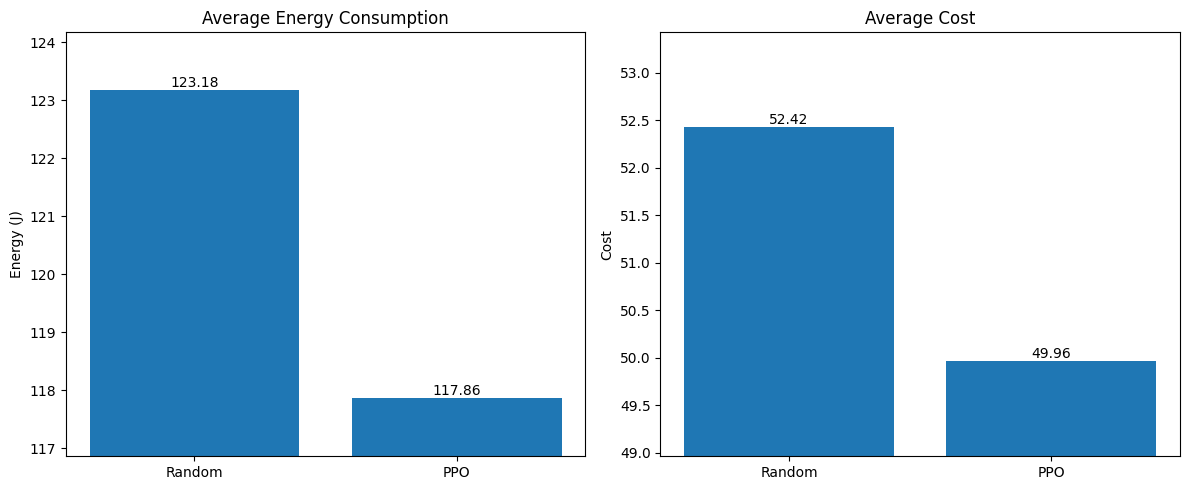

In [26]:
import matplotlib.pyplot as plt

energy = [Random_Avg_Energy, PPO_Avg_Energy]
cost = [Random_Avg_Cost, PPO_Avg_Cost]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bars = axes[0].bar(['Random', 'PPO'], energy)
axes[0].set_title('Average Energy Consumption')
axes[0].set_ylabel('Energy (J)')

# Zoom axis
axes[0].set_ylim(min(energy) - 1, max(energy) + 1)

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

# Cost
bars = axes[1].bar(['Random', 'PPO'], cost)
axes[1].set_title('Average Cost')
axes[1].set_ylabel('Cost')

axes[1].set_ylim(min(cost) - 1, max(cost) + 1)

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [27]:
model.save("ppo_offloading_model")
print("Model saved.")

Model saved.


In [28]:
from stable_baselines3 import PPO

model = PPO.load("ppo_offloading_model", env=env)
print("Model loaded.")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded.


In [29]:
import os
os.getcwd()

'/content'

In [31]:
!ls -lh /content

total 208K
-rw-r--r-- 1 root root 201K Jun 10 06:14 ppo_offloading_model.zip
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [32]:
from google.colab import files
files.download('/content/ppo_offloading_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>